Import libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

Import file

In [98]:
iplData = pd.read_csv('IPL_Dataset.csv')
iplData.head()

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30


In [130]:
iplData.isnull().sum().sort_values(ascending=False)

Jersey No                0
Strike rate              0
lastName                 0
firstName                0
6s                       0
4s                       0
50                       0
100                      0
Balls faced              0
Player                   0
Avg                      0
Highest Score            0
Runs                     0
Not Out                  0
Inns                     0
Matches                  0
Cleaned_Highest_score    0
dtype: int64

Q1. What is the maximum number of matches played by an individual player in a season? Print the player name along with the number of matched played.

In [328]:
iplData.loc[(iplData['Matches']== iplData['Matches'].max()),['Player', 'Matches']]


,Player,Matches
1,Shikhar Dhawan,17
3,Shreyas Iyer,17
19,Marcus Stoinis,17
67,Kagiso Rabada,17


Q2. Top 2 players with maximum Average who have scored atleast 2 half centuries ?

In [332]:
#who have scored atleast 2 half centuries
gtFifty = iplData.loc[(iplData['50'] > 2)]
#maximum Average
gtFifty = gtFifty.sort_values("Avg", ascending=False).head(2)
print(gtFifty[["Player", "Avg", "50"]])


         Player    Avg  50
4  Ishan Kishan  57.33   4
0      KL Rahul  55.83   5


Q3. Create 2 new columns based on Player name. First column will have first name and second column will have last name. Eg: for the player Shikhar Dhawan, Shikhar will be the first name and Dhawan will be the last name.

In [108]:
iplData[['firstName','lastName']]=iplData['Player'].str.split(" ", n=1, expand=True)
iplData


,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,firstName,lastName
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0,Khaleel,Ahmed
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0,Arshdeep,Singh
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0,Daniel,Sams
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0,Shreevats,Goswami


Q4. Create a new column (Cleaned_Highest_score) based on Highest score variable. Remove the Asterik(*) mark and convert the data type into INT.

In [119]:
iplData['Cleaned_Highest_score'] = pd.to_numeric(iplData['Highest Score'].str.replace('*',''))
iplData

,Jersey No,Player,Matches,Inns,Not Out,Runs,Highest Score,Avg,Balls faced,Strike rate,100,50,4s,6s,firstName,lastName,Cleaned_Highest_score
0,1,KL Rahul,14,14,2,670,132*,55.83,518,129.34,1,5,58,23,KL,Rahul,132
1,2,Shikhar Dhawan,17,17,3,618,106*,44.14,427,144.73,2,4,67,12,Shikhar,Dhawan,106
2,3,David Warner,16,16,2,548,85*,39.14,407,134.64,0,4,52,14,David,Warner,85
3,4,Shreyas Iyer,17,17,2,519,88*,34.60,421,123.27,0,3,40,16,Shreyas,Iyer,88
4,5,Ishan Kishan,14,13,4,516,99,57.33,354,145.76,0,4,36,30,Ishan,Kishan,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,129,Khaleel Ahmed,7,1,0,0,0*,0.00,2,0.00,0,0,0,0,Khaleel,Ahmed,0
129,130,Arshdeep Singh,8,1,0,0,0*,0.00,3,0.00,0,0,0,0,Arshdeep,Singh,0
130,131,Daniel Sams,3,1,0,0,0*,0.00,2,0.00,0,0,0,0,Daniel,Sams,0
131,132,Shreevats Goswami,2,2,0,0,0*,0.00,4,0.00,0,0,0,0,Shreevats,Goswami,0


Q5. Print the total number of centuries scored in the entire season.

In [334]:
iplData['100'].sum()

5

Q6. Print all the player names whose strike rate is less than the average strike rate of all players in entire season. Print the player name, his strike rate and average strike rate.

In [152]:
avgStrikeRate = iplData['Strike rate'].mean()
avgStrikeRate
lessAvgDf = iplData[iplData['Strike rate']<avgStrikeRate]
lessAvgDf
for i, row in lessAvgDf.iterrows():
    print(f"Player: {row['Player']}, Strike Rate: {row['Strike rate']}, Avg Strike Rate: {avgStrikeRate}")

Player: Ajinkya Rahane, Strike Rate: 105.6, Avg Strike Rate: 107.36473684210526
Player: Glenn Maxwell, Strike Rate: 101.88, Avg Strike Rate: 107.36473684210526
Player: Vijay Shankar, Strike Rate: 101.04, Avg Strike Rate: 107.36473684210526
Player: Josh Philippe, Strike Rate: 101.29, Avg Strike Rate: 107.36473684210526
Player: Gurkeerat Singh, Strike Rate: 88.75, Avg Strike Rate: 107.36473684210526
Player: Kedar Jadhav, Strike Rate: 93.93, Avg Strike Rate: 107.36473684210526
Player: Yashasvi Jaiswal, Strike Rate: 90.9, Avg Strike Rate: 107.36473684210526
Player: Shreyas Gopal, Strike Rate: 94.87, Avg Strike Rate: 107.36473684210526
Player: Murali Vijay, Strike Rate: 74.41, Avg Strike Rate: 107.36473684210526
Player: Chris Jordan, Strike Rate: 93.54, Avg Strike Rate: 107.36473684210526
Player: Navdeep Saini, Strike Rate: 100.0, Avg Strike Rate: 107.36473684210526
Player: Kamlesh Nagarkoti, Strike Rate: 70.96, Avg Strike Rate: 107.36473684210526
Player: Harshal Patel, Strike Rate: 87.5, A

Q7. Please check the correlation between the features and create a heat map.



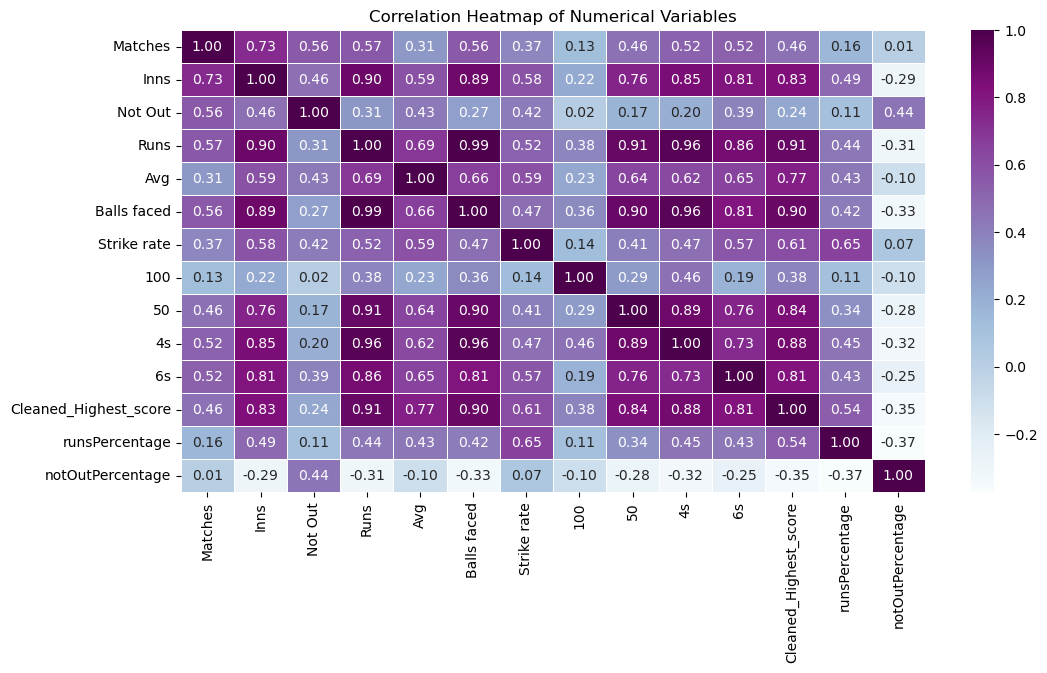

In [336]:
###Find the numeric data coloumns
numeric_Col= [fea for fea in iplData.columns if iplData[fea].dtypes !='object']
numeric_Col
###Extract the numeric data 
numeric_data = iplData[numeric_Col]
###Drop the Jersey number key field
numeric_data = numeric_data.drop('Jersey No',axis=1)
numeric_data
# Correlation heatmap (numerical variables only)
plt.figure(figsize=(12, 6))
sns.heatmap(numeric_data.corr(), annot=True, cmap="BuPu", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

Q8. Check the list of players who has an average greater than 50 as well strike rate above 120. Print player name, average and strike rate.

In [338]:
iplData.loc[(iplData['Avg']>50) & (iplData['Strike rate']> 120) ,['Player','Avg','Strike rate']]


,Player,Avg,Strike rate
0,KL Rahul,55.83,129.34
4,Ishan Kishan,57.33,145.76
31,Kieron Pollard,53.60,191.42
36,Wriddhiman Saha,71.33,139.86
37,Ruturaj Gaikwad,51.00,120.71
57,Deepak Hooda,101.00,142.25
60,Tom Curran,83.00,133.87


Q9. Please check the list of players who has an average greater than 40 and balls faced above 100. Print player name, average and balls faced.

In [340]:
iplData.loc[(iplData['Avg']>40) & (iplData['Balls faced']> 100) ,['Player','Avg','Balls faced']]

,Player,Avg,Balls faced
0,KL Rahul,55.83,518
1,Shikhar Dhawan,44.14,427
4,Ishan Kishan,57.33,354
8,Virat Kohli,42.36,384
9,ABD Villiers,45.40,286
10,Faf Duplessis,40.81,319
14,Eoin Morgan,41.80,302
24,Kane Williamson,45.28,237
27,Chris Gayle,41.14,210
28,Ben Stokes,40.71,200


Q10. Players who scored atleast one century in this season. Create visualization.

<Figure size 1000x500 with 0 Axes>

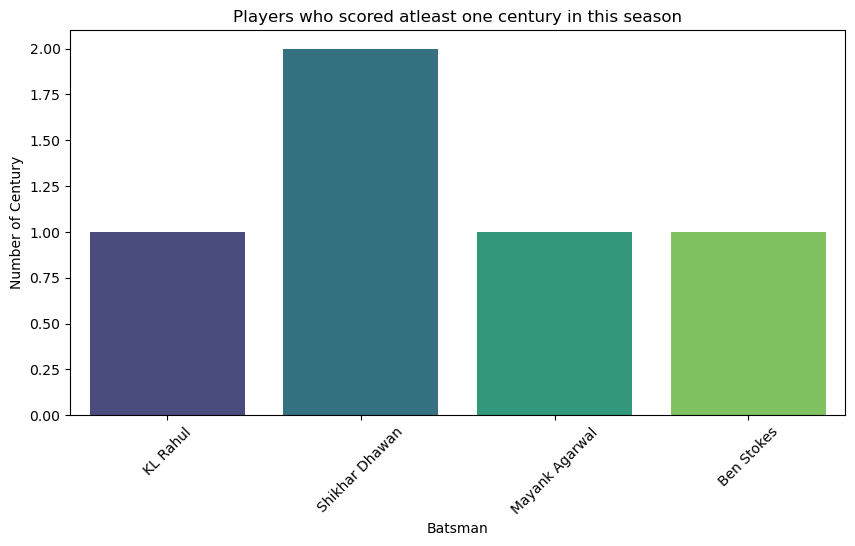

In [228]:
player_century =iplData.loc[(iplData['100']>=1 ) ,['Player','100']].copy()
player_century

# Plot the data
plt.figure(figsize=(10, 5))
sns.barplot(x='Player', y='100', data=player_century, palette="viridis")
plt.title("Players who scored atleast one century in this season")
plt.xlabel("Batsman")
plt.ylabel("Number of Century")
plt.xticks(rotation=45)
plt.show()

Q11. Players who scored atleast 4 half centuries in this season.

In [235]:
iplData.loc[(iplData['50']>=4 ),['Player','50']]

,Player,50
0,KL Rahul,5
1,Shikhar Dhawan,4
2,David Warner,4
4,Ishan Kishan,4
5,Quinton Kock,4
6,Suryakumar Yadav,4
7,Devdutt Padikkal,5
9,ABD Villiers,5
10,Faf Duplessis,4


Q12. Check the list of players who hit more than 45 boundaries and more than 10 sixes in this season.

In [238]:
iplData.loc[(iplData['4s']>45 ) & (iplData['6s']>10 ) ,['Player','4s','6s']]

,Player,4s,6s
0,KL Rahul,58,23
1,Shikhar Dhawan,67,12
2,David Warner,52,14
5,Quinton Kock,46,22
6,Suryakumar Yadav,61,11


Q13. Plot a histogram of number of matches played in a season by players.

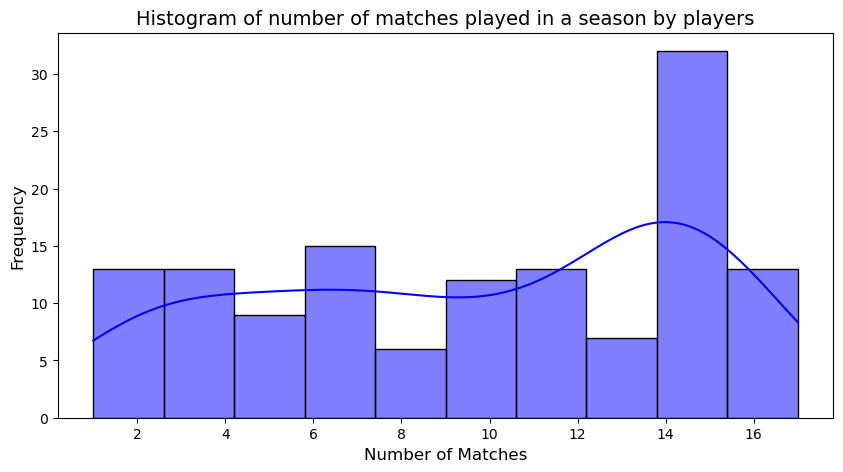

In [253]:
plt.figure(figsize=(10, 5))
sns.histplot(iplData["Matches"], bins=10, kde=True, color="blue")  # kde=True adds a smooth density curve

plt.xlabel("Number of Matches", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of number of matches played in a season by players", fontsize=14)
plt.show()

Q14. Plot the histogram of balls faced by players.

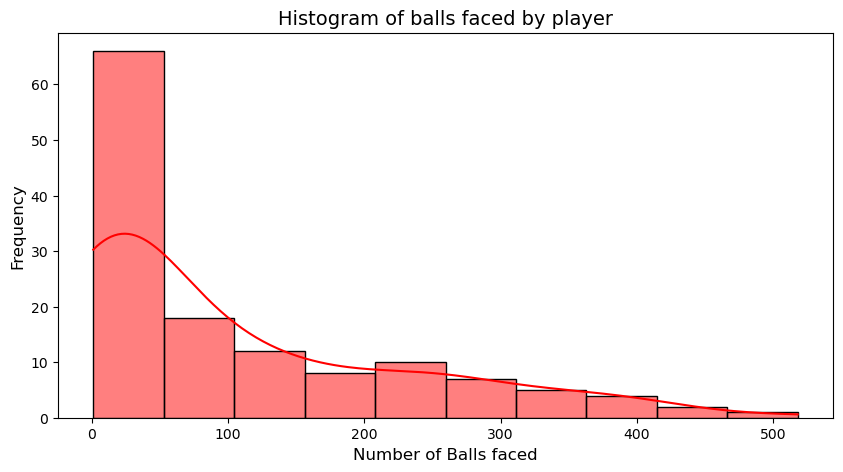

In [266]:
plt.figure(figsize=(10, 5))
sns.histplot(iplData["Balls faced"], bins=10, kde=True, color="Red")  # kde=True adds a smooth density curve

plt.xlabel("Number of Balls faced", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Histogram of balls faced by player", fontsize=14)
plt.show()

Q15. Top 10 players with most runs in a season

In [279]:
topTen = iplData.sort_values('Runs', ascending=False).head(10)  
topTen[['Player','Runs']]

,Player,Runs
0,KL Rahul,670
1,Shikhar Dhawan,618
2,David Warner,548
3,Shreyas Iyer,519
4,Ishan Kishan,516
5,Quinton Kock,503
6,Suryakumar Yadav,480
7,Devdutt Padikkal,473
8,Virat Kohli,466
9,ABD Villiers,454


Q16. Print the players who played the match but didn't get the batting.

In [298]:
notBatted = iplData[iplData["Inns"] == 0][["Player", "Matches", "Inns"]]
notBatted

,Player,Matches,Inns


Q17. Create a new column to show the percentage of total runs scored in 4s and 6s. Then print the top 5 players with maximum percentage.

In [307]:
iplData['runsPercentage']=((iplData['4s'] + iplData['6s'])/iplData['Runs'])*100
iplData.sort_values('runsPercentage',ascending=False).head(5)[['Player','runsPercentage']]

,Player,runsPercentage
97,Mohammad Nabi,18.181818
109,Andrew Tye,16.666667
81,Nathan Coulternile,16.000000
18,Nitish Rana,15.625000
26,Shane Watson,15.384615


Q18. Print the players with top 5 Not out percentages (Not Out percentage can be calculated as number of Not outs divided by Innings).

In [312]:
iplData['notOutPercentage']=(iplData['Not Out']/iplData['Inns'])*100
iplData.sort_values('notOutPercentage',ascending=False).head(5)[['Player','notOutPercentage']]

,Player,notOutPercentage
122,Shahbaz Ahmed,100.0
97,Mohammad Nabi,100.0
114,T Natarajan,100.0
116,Rahul Chahar,100.0
113,Dhawal Kulkarni,100.0


Q19. Create visualization of top 10 players with highest number of sixes.

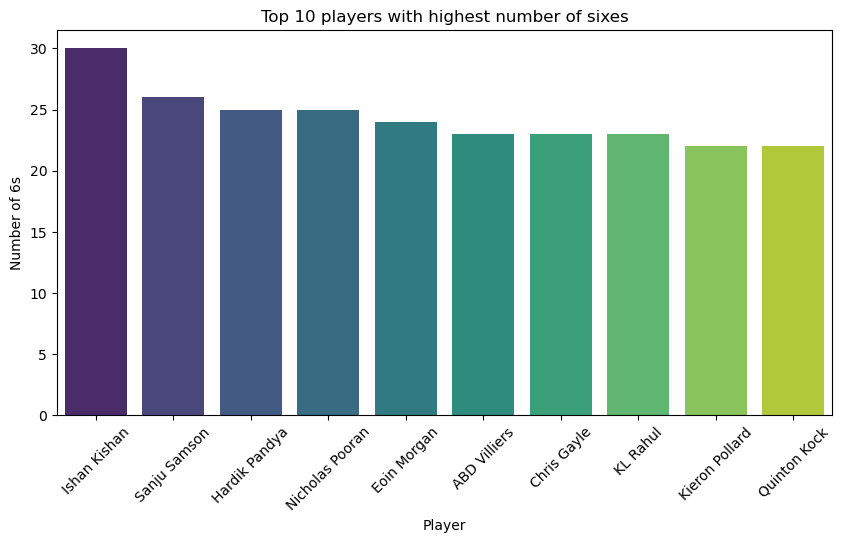

In [315]:
top_sixes = iplData.sort_values('6s',ascending=False).head(10)[['Player','6s']]
# Plot the data
plt.figure(figsize=(10, 5))
sns.barplot(x='Player', y='6s', data=top_sixes, palette="viridis")
plt.title("Top 10 players with highest number of sixes")
plt.xlabel("Player")
plt.ylabel("Number of 6s")
plt.xticks(rotation=45)
plt.show()

Q20. Scatter plot of runs scored by a player v/s balls faced in a season. Then find the relationship between these 2 variables.

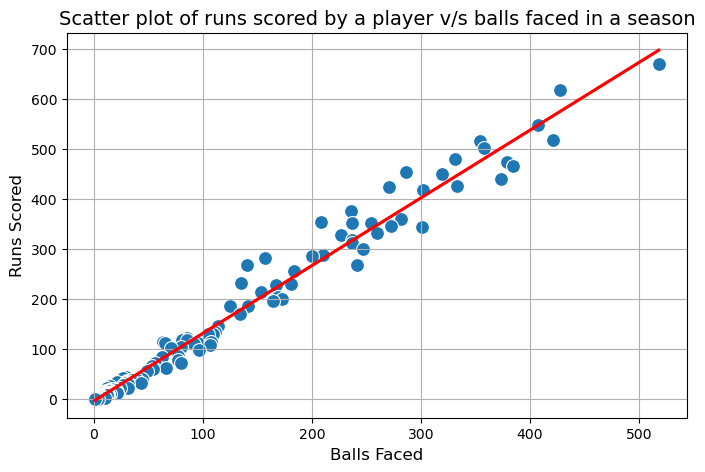

In [326]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=iplData["Balls faced"], y=iplData["Runs"], s=100, palette="viridis")

sns.regplot(x=iplData["Balls faced"], y=iplData["Runs"], scatter=False, color="red", ci=None)

plt.xlabel("Balls Faced", fontsize=12)
plt.ylabel("Runs Scored", fontsize=12)
plt.title("Scatter plot of runs scored by a player v/s balls faced in a season", fontsize=14)
plt.grid(True)

# Show the plot
plt.show()